<a href="https://colab.research.google.com/github/tanay-pingalkar/Programming-Data-structures-and-Algorithm-in-Python/blob/main/Introduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction


In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt

## Why complexity matters?
Suppose a goverment wants create a list of sim cards whose holder is actually a person in the country and discontinue the bad sim cards. It can do so if for each sim card, if it finds an aadhar card to which the details of sim card match, then that sim card is valid otherwise it is not.
### Pseudo code
```
for each Sim from SimList
    for each AadhaarCard from AadhaarCardList
        if Sim details match AadharDetails
            add Sim to ValidSimList
            next sim
```

In India, there are approx. $10^9$ people and $10^9$ sim cards (since one person has multiple sim card).
Then there are in total $10^9\cdot10^9=10^{18}$ that the code perform.

Note that python performs approx $10^7$ operations in a second, so the time to perform $10^{18}$ is $10^{18}/10^7=10^{11}$ seconds.

$10^{11}$ seconds = $10^{11}/60 \approx 1.67 \times 10^9$ minutes = $(1.67 \times 10^9)/60 \approx 2.8 \times 10^7$ hours = $(2.8 \times 10^7)/24 \approx 1.17 \times 10^6$ days = $(1.17 \times 10^6)/365 = 3200$ years!!

In [ ]:
# number of seconds required to python to compute 10^7 basic operation
start = time.perf_counter()
i=0
while i <= 10**7:
    i+=1

end = time.perf_counter()
print(end-start)

0.9174947359999805


## Complexity

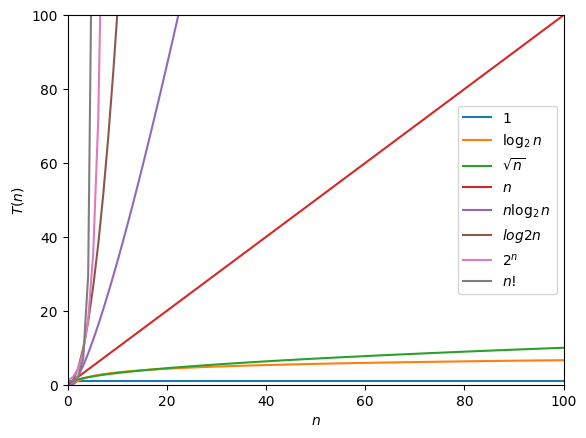

In [ ]:
n = np.linspace(0.1,100,100)
plt.plot(n,[1 for i in n], label="1")
plt.plot(n, np.log2(n), label=r"$\log_2n$")
plt.plot(n,np.sqrt(n), label=r"$\sqrt{n}$")
plt.plot(n,n, label="$n$")
plt.plot(n,n*np.log2(n), label=r"$n\log_2n$")
plt.plot(n,n**2,label=r"$log2n$")
plt.plot(n,2**n, label=r"$2^n$")
from scipy.special import factorial
plt.plot(n, factorial(n), label=r"$n!$")
plt.xlabel("$n$")
plt.ylabel("$T(n)$")
plt.ylim(0,100)
plt.xlim(0,100)


plt.legend()

**Upper bound.** $f(x)$ is $O(g(x))$ if there is are constants $c$ and $x_0$ such that $f(x) \leq cg(x)$ for $x \geq x_0$.

**Example.** $100n+5$ is $O(n^2)$

Text(100, 19600, '$cn^3$ where $c = 1$')

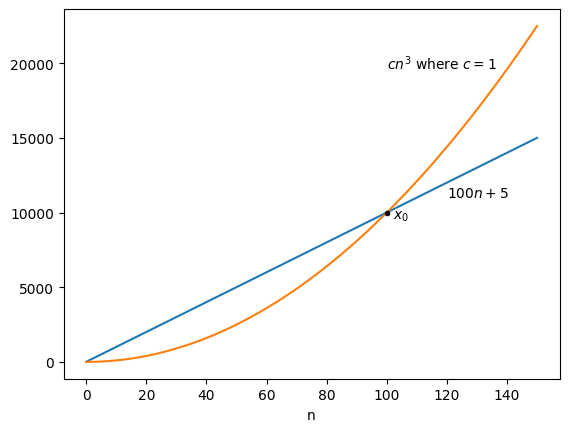

In [ ]:
n = np.linspace(0,150,151)
plt.plot(n, 100*n+5)
plt.plot(n, n**2)
plt.plot(100, 100**2, "ko", ms = 3)
plt.annotate("$x_0$", xy = (100, 100**2),xytext=(100+2,98**2))
plt.xlabel("n")
plt.annotate("$100n+5$", xy = (120, 100*120+5), xytext=(120, 100*110+5))
plt.annotate("$cn^3$ where $c = 1$", xy=(120,120**2), xytext=(100,140**2))

**Non-example.** $n^3$ is not $O(n^2)$

## Finding maximum and minimum element in the list

In [ ]:
def max_of_list(li):
    max_el = li[0]

    for el in li[1:]:
        if el > max_el:
            max_el = el

    return max_el

def min_of_list(li):
    max_el = li[0]

    for el in li[1:]:
        if el < max_el:
            max_el = el

    return max_el

In [ ]:
max_of_list([2,3,5,6,2,3,4]),min_of_list([2,3,5,6,2,3,4])

(6, 2)

## Checking whether a list contains a dublicate element

In [ ]:
def has_dublicate(li):
    for i in range(len(li)):
         for el in li[i+1:]:
            if el == li[i]:
              return True
    return False

In [ ]:
has_dublicate([2,3,4,4,8]), has_dublicate([2,3,4,41,8])

(True, False)

## Matrix multiplication

In [ ]:
class Mat():
  def __init__(self,mat):
    self.mat = mat
    self.rows = len(mat)
    self.columns = len(mat[0])

  def __repr__(self):
    return f"matrix:{self.mat}, rows:{self.rows}, columns:{self.columns}"

  def __getitem__(self,index):
    return self.mat[index]

  def __setitem__(self,index,value):
    self.mat[index] = value

  def __mul__(A, B):
    if A.columns != B.rows:
      raise TypeError("not a valid multiplication")

    m = A.rows
    k = A.columns
    n = B.columns

    def ij(i,j):
      return sum([A[i][k]*B[k][j] for k in range(k)])

    def row(i):
      return [ij(i,j) for j in range(n)]

    return Mat([row(i) for i in range(m)])

In [ ]:
A = Mat([[1,32,3],[1,2,3],[1,2,4]])
B = Mat([[1,2],[1,2],[1,2]])
A,B,A*B

(matrix:[[1, 32, 3], [1, 2, 3], [1, 2, 4]], rows:3, columns:3,
 matrix:[[1, 2], [1, 2], [1, 2]], rows:3, columns:2,
 matrix:[[36, 72], [6, 12], [7, 14]], rows:3, columns:2)

## Towers of Hanoi

In [ ]:
from IPython.display import clear_output

class TowersOfHanoi:
  def __init__(self,height=4, peg_cell="_"):
    self.h = height
    self.relaxation = 0.1
    self.peg_cell=peg_cell

    self.hanoi = {"A" : [self.h-i for i in range(self.h)],
                  "B" : [],
                  "C" : []}

  def print(self):
    hindex = self.h-1
    for i in range(self.h):
      for tower in ["A","B","C"]:
        tower = self.hanoi[tower]
        if hindex - i < len(tower):
          print(f"{self.peg_cell*(2*tower[hindex-i]):^{2*self.h}}",end="")
        else:
          print(" "*(2*self.h),end="")
      print("")

  def move(self,source,target):
    if len(self.hanoi[target]) != 0:
      if self.hanoi[source][-1] > self.hanoi[target][-1]:
        raise IndexError("Cannot move big disk over small disk")

    self.hanoi[target].append(self.hanoi[source][-1])
    self.hanoi[source].pop()
    clear_output(wait=True)
    self.print()
    time.sleep(self.relaxation)

  def solve(self,n, source, target, spare):
    if n-1 != 0: self.solve(n-1, source, spare,target)
    self.move(source,target)
    if n-1 !=0: self.solve(n-1, spare,target, source)

  def solution(self,relaxation=0.1):
    self.relaxation = relaxation
    self.print()
    if self.h-1 != 0: self.solve(self.h-1, "A", "C","B")
    self.move("A","B")
    if self.h-1 != 0: self.solve(self.h-1, "C", "B","A")

In [ ]:
TowersOfHanoi(5).solution(0.5)

              __              
             ____             
            ______            
           ________           
          __________          


## Gcd
$\gcd(m,n)$ is the largest number which divides both $m$ and $n$.
For example, $\gcd(8,12) = 4$ and $\gcd(18,25)=1$.
Note that $\gcd(m,n)$ always exists as $1$ divides every $m,n \in \mathbb{N}$.

In [ ]:
def gcd(m,n):
    cf = [] # list of common factors
    for i in range(1,min(m,n)+1):
        if m%i == 0 and n%i == 0:
            cf.append(i)

    return cf[-1] # cf[len(cf)-1]

In [ ]:
# since only the last common factor is important

def gcd(m,n):
    for i in range(1,min(n,m)+1):
         if m%i == 0 and n%i == 0:
            lcf = i # latest common factor and no need to initialize it

    return lcf

In [ ]:
# alternatively
def gcd(m,n):
    lcf = 1
    for i in range(2,min(n,m)+1):
         if m%i == 0 and n%i == 0:
            lcf = i # latest common factor
    return lcf

**Lemma.** Let $b > a$. Then $\gcd(a,b) = \gcd(a,b-a)$.

**Proof.** Let $d = \gcd(a,b)$, then $d | a$ and $d | b$ moreover $d$ is largest such $d$. Hence we have, $a = qd$ and $b = q'd$ for some $q,q' \in \mathbb{N}$. Then $b-a = (q'-q)d$, which implies that $d | b-a$. If $d'$ is a common divisor of $a, b-a$, then $d'| (b-a)+a$, i.e, $d' | b$, which implies that $d'$ is a common divisor of $a,b$. Since $d$ is the maximum common divisor of $a,b$, we have $d'\leq d$. Hence $d$ is also the maximum commmon divisor of $a$ and $b-a$ as desired.

In [ ]:
def gcd(m,n):
    maxi, mini = max(m,n), min(m,n)

    if maxi%mini == 0:
        return mini
    else:
        return gcd(mini, maxi-mini)

**Lemma (Euclid's algorithm).** If $a = qb+r$ then $\gcd(a,b)=\gcd(a,r)$.

**Proof.** Similar to last proof.

In [ ]:
def gcd(m,n):
    maxi, mini = max(m,n), min(m,n)

    if maxi%mini == 0:
        return mini
    else:
        return gcd(mini, maxi%mini)

## Prime numbers
A prime number is a number which has exactly two distinct factors. Since a number is always divisible by 1 and itself, equivalently a number is prime if it is divisible by 1 and itself, moreover that number is not 1, so as to satisfy the distinctiveness of factors.

In [ ]:
def factors(n):
  factorslist = []

  for i in range(1,n+1):
    if n%i == 0:
      factorslist.append(i)
  return factorslist

In [ ]:
def is_prime(n):
  return factors(n) == [1,n]

In [ ]:
def is_prime(n):
  return len(factors(n)) == 2

In [ ]:
def is_prime(n):
  ans = True
  for i in range(2,n):
    if n%i == 0:
      ans = False
  return ans